# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DipeshGhimire33/Flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The final Opportunity Score ranks all content pages from highest to lowest priority for human review. Pages with higher scores show a stronger combination of recent performance decline, older content, meaningful search visibility, ranking opportunity, and CTR opportunity.

Each page receives reason codes explaining why it was prioritized, such as `DECLINING_PERFORMANCE`, `STALE_CONTENT`, `HIGH_VISIBILITY`, `RANKING_OPPORTUNITY`, and `CTR_OPPORTUNITY`. The recommended action for high-ranked pages is **REVIEW_FOR_REFRESH**, not automatic refreshing; reviewers should check the page and business context before deciding whether a refresh is appropriate.



In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

The Opportunity Score is intended for content and SEO teams to prioritize pages for human review and identify pages that may be worth investigating for a refresh. It supports review decisions by summarizing measurable signals such as performance change, freshness, visibility, ranking, and CTR.

The score does not predict whether a refresh will succeed, prove that a page needs updating, or replace editorial and business judgment. It may also be affected by missing data, temporary traffic changes, incomplete history, and factors not captured in the dataset.


In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Before acting on a high-ranked page, a human reviewer should check the page quality, search intent, content accuracy, recent traffic context, business importance, and whether the decline appears temporary or meaningful. Missing or unusual data should also be investigated before taking action.

The score should never automatically publish, rewrite, delete, or refresh content. It should not make final editorial, business, or SEO decisions without human review. The ranking is a decision-support tool, not an automated action system.


In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The recommendations should be reviewed if the underlying traffic patterns, content freshness, or data availability change substantially. Triggers include a large increase in missing values, changes in the distribution of key signals, changes in how performance is measured, or evidence that high-ranked pages are no longer useful during human review.

Because the current approach is rule-based rather than trained, it does not require traditional model retraining. Instead, the scoring rules and thresholds should be revalidated and updated when the data or content environment changes.


In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

# Performance decline signal
impression_change = (
    (df["impressions_prev_30d"] - df["impressions_last_30d"])
    / df["impressions_prev_30d"].replace(0, np.nan)
)

click_change = (
    (df["clicks_prev_30d"] - df["clicks_last_30d"])
    / df["clicks_prev_30d"].replace(0, np.nan)
)

decline_signal = (
    (impression_change.clip(lower=0) +
     click_change.clip(lower=0)) / 2
)

# Freshness signal
freshness_signal = df["days_since_last_update"].fillna(
    df["days_since_last_update"].median()
)
freshness_signal = (
    freshness_signal /
    freshness_signal.quantile(0.95)
).clip(0, 1)

# Visibility signal
visibility_signal = np.log1p(
    df["impressions_90d"].fillna(0)
)
visibility_signal = (
    visibility_signal /
    visibility_signal.quantile(0.95)
).clip(0, 1)

# Ranking opportunity
position = df["avg_position"].replace(0, np.nan)
position_signal = ((position - 1) / 49).clip(0, 1).fillna(0)

# CTR opportunity
ctr_signal = (
    1 -
    df["ctr"].fillna(df["ctr"].median()) / 100
).clip(0, 1)

# Opportunity Score
df["opportunity_score"] = (
    0.30 * decline_signal.fillna(0)
    + 0.20 * freshness_signal
    + 0.20 * visibility_signal
    + 0.15 * position_signal
    + 0.15 * ctr_signal
)

# Reason codes
def get_reasons(row):
    reasons = []

    if row["impressions_last_30d"] < row["impressions_prev_30d"]:
        reasons.append("DECLINING_PERFORMANCE")

    if row["days_since_last_update"] >= 180:
        reasons.append("STALE_CONTENT")

    if row["impressions_90d"] > df["impressions_90d"].median():
        reasons.append("HIGH_VISIBILITY")

    if 2 <= row["avg_position"] <= 20:
        reasons.append("RANKING_OPPORTUNITY")

    if row["ctr"] < df["ctr"].median():
        reasons.append("CTR_OPPORTUNITY")

    return "|".join(reasons)

df["reason_codes"] = df.apply(get_reasons, axis=1)

# Rank all pages
df = df.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

df["priority_rank"] = df.index + 1

# Create output folder
os.makedirs("../../work/outputs", exist_ok=True)

# Export queue
output_cols = [
    "content_id",
    "opportunity_score",
    "priority_rank",
    "reason_codes"
]

queue = df[output_cols].copy()

queue.to_csv(
    "../../work/outputs/baseline_action_score.csv",
    index=False
)

print("Queue saved successfully.")
print("Rows exported:", len(queue))
print(queue.head(10))

Queue saved successfully.
Rows exported: 30000
             content_id  opportunity_score  priority_rank  \
0  content_fb66dd8f4629           0.977913              1   
1  content_9623e642ff3a           0.950456              2   
2  content_045de7f327fe           0.944312              3   
3  content_058efde65398           0.927207              4   
4  content_3dbf0b8caf06           0.926736              5   
5  content_061b51236cbd           0.922633              6   
6  content_8b1eeb87a7c5           0.922307              7   
7  content_581f85ef23d3           0.921521              8   
8  content_bba7a7a249b2           0.921460              9   
9  content_9b8a4ceacea5           0.917693             10   

                                        reason_codes  
0              DECLINING_PERFORMANCE|HIGH_VISIBILITY  
1  DECLINING_PERFORMANCE|HIGH_VISIBILITY|CTR_OPPO...  
2  DECLINING_PERFORMANCE|HIGH_VISIBILITY|CTR_OPPO...  
3  DECLINING_PERFORMANCE|HIGH_VISIBILITY|CTR_OPPO...  
4     

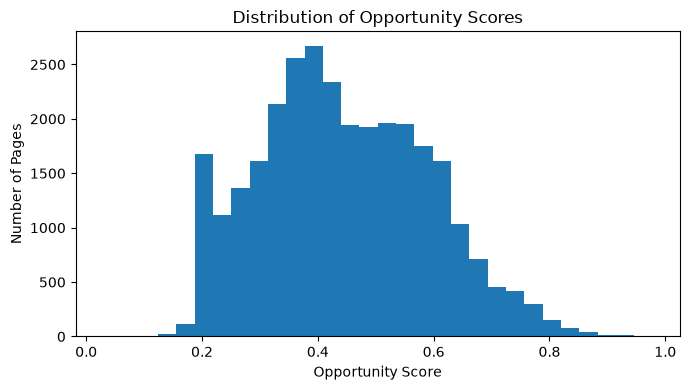

Figure saved successfully.


In [11]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["opportunity_score"].dropna(),
    bins=30
)

plt.title("Distribution of Opportunity Scores")
plt.xlabel("Opportunity Score")
plt.ylabel("Number of Pages")

plt.tight_layout()

plt.savefig(
    "../../work/outputs/opportunity_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.